In [ ]:
import numpy as np
from utils.fcfd_unpacker import FCFD_unpacker
from utils.fcfd_time_reconstruction import time_reconstruction
import matplotlib.pyplot as plt
import mplhep as hep
plt.style.use([hep.style.ROOT, hep.style.firamath])

In [24]:
config = {}
config["tdc_encoder"]=0
unpacker = FCFD_unpacker(config)
import json
with open("./test_result/test_time_internal.json", "r") as json_file:
    data = json.load(json_file)

scan_values = [4, 8, 16, 32]
ts = [[] for _ in scan_values]

for scan_index, scan_value in enumerate(scan_values):
    packages = unpacker.parse_to_dataframes(data[f"{scan_value}"])
    for p in packages:
        parsed = unpacker.parse_dataframe(p)
        tdc = parsed['tdc'][0]
        t = time_reconstruction(tdc['CLK_TAG'],scan_value,tdc['CAL0'],tdc['CAL_SUM'],tdc['TOA0'],tdc['TOA_SUM'])
        chid = tdc['CH_ID']
        if chid !=0:
            raise ValueError
        ts[scan_index].append(t)





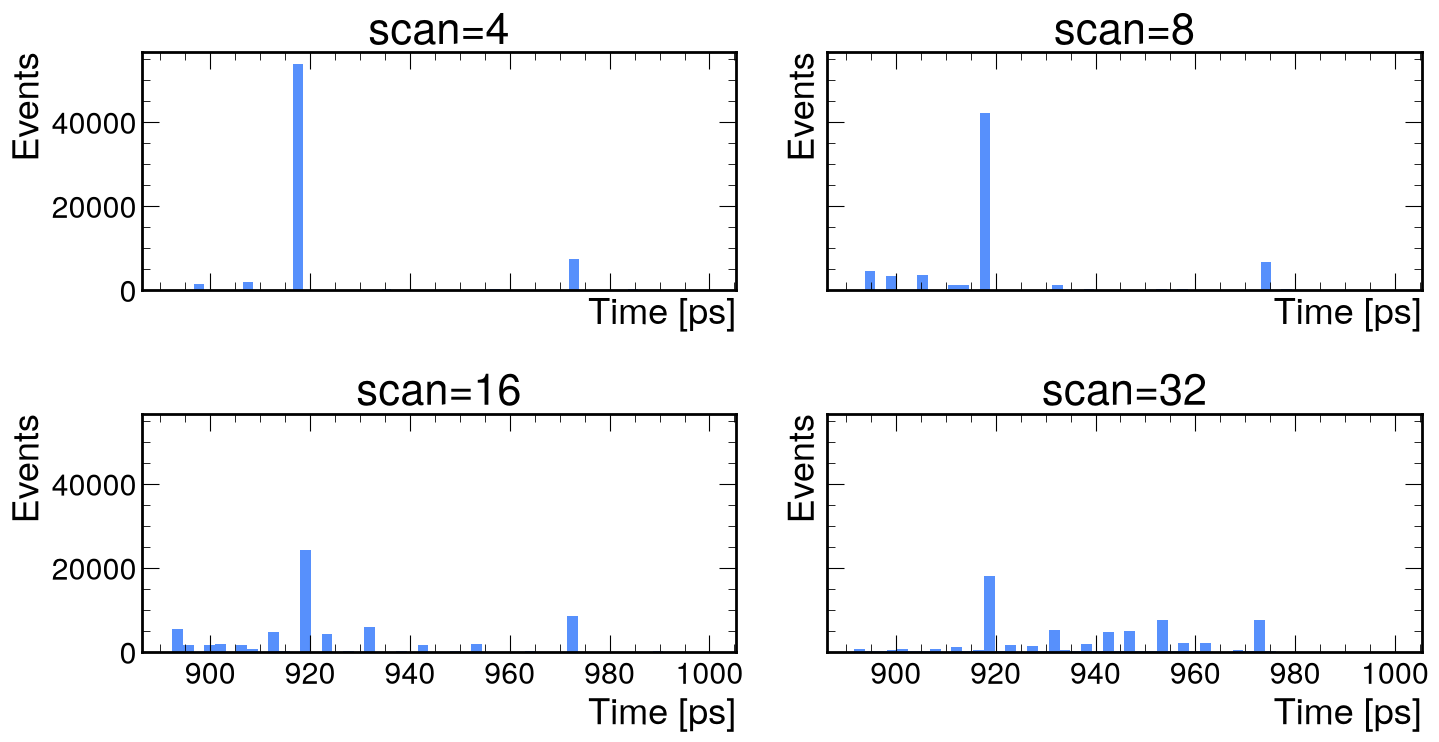

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True, sharey=True)

for scan_index, scan_value in enumerate(scan_values):
    axis = axes.flat[scan_index]
    axis.hist(ts[scan_index], bins=50)
    axis.set_title(f"scan={scan_value}")
    axis.set_xlabel("Time [ps]")
    axis.set_ylabel("Events")

fig.tight_layout()